In [1]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sales'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'),
    ('order_items.csv', 'order_items')# Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='#Arti14@',
    database='E_Commerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = '/Users/akshaybisht/Python to SQL project/CSV Files'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Processing sellers.csv
NaN values before replacement:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Processing products.csv
NaN values before replacement:
product_id                      0
product category              610
product_name_length           610
product_description_length    610
product_photos_qty            610
prod

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

In [3]:
db = mysql.connector.connect(host='localhost',
                             user='root',
                             password='#Arti14@',
                             database='E_Commerce')

cur = db.cursor()

##  List all unique cities where customers are located. 

In [4]:
query = """ SELECT DISTINCT(customer_city) FROM customers"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data)
df.head()

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


## Count the number of orders placed in 2017.

In [5]:
query = """ SELECT COUNT(order_id) FROM orders 
            WHERE YEAR(order_purchase_timestamp) = 2017 """

cur.execute(query)

data = cur.fetchall()

"Total orders placed in year 2017 is :", data[0][0]

('Total orders placed in year 2017 is :', 225505)

##  Find the total sales per category.

In [6]:
query = """ SELECT p.product_category, SUM(pay.payment_value) AS Total_Sales 
            FROM products p JOIN order_items o 
            ON p.product_id = o.product_id 
            JOIN payments pay ON o.order_id = pay.order_id
            GROUP BY p.product_category"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Product Category","Total Sales"])
df

,Product Category,Total Sales
0,perfumery,6.334233e+07
1,Furniture Decoration,1.787720e+08
2,telephony,6.086026e+07
3,bed table bath,2.140692e+08
4,automotive,1.065368e+08
...,...,...
69,cds music dvds,1.499288e+05
70,La Cuisine,3.641913e+05
71,Fashion Children's Clothing,9.820875e+04
72,PC Gamer,2.718038e+05


##  Calculate the percentage of orders that were paid in installments.

In [7]:
query = """ SELECT (SUM(CASE WHEN payment_installments >= 1
            THEN 1 else 0 END)/COUNT(order_id))*100 FROM payments"""

cur.execute(query)

data = cur.fetchall()

'The percentage of orders that were paid in installments is ',data[0][0]

('The percentage of orders that were paid in installments is ',
 Decimal('99.9981'))

##  Count the number of customers from each state. 

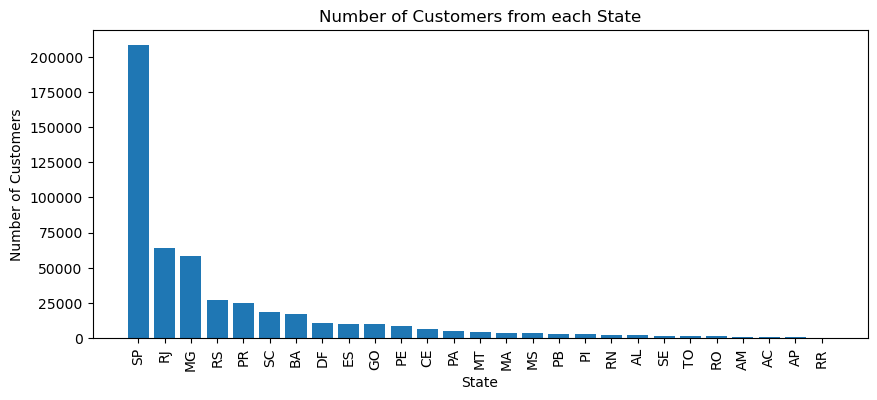

In [8]:
query = """ SELECT customer_state, COUNT(customer_id)
            FROM customers GROUP BY customer_state"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["State","No. of Customers"])
df = df.sort_values(by = 'No. of Customers', ascending = False)

plt.figure(figsize = (10,4))
plt.bar(df["State"], df["No. of Customers"])
plt.xticks(rotation = 90)
plt.title("Number of Customers from each State")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.show()

##  Calculate the number of orders per month in 2018.

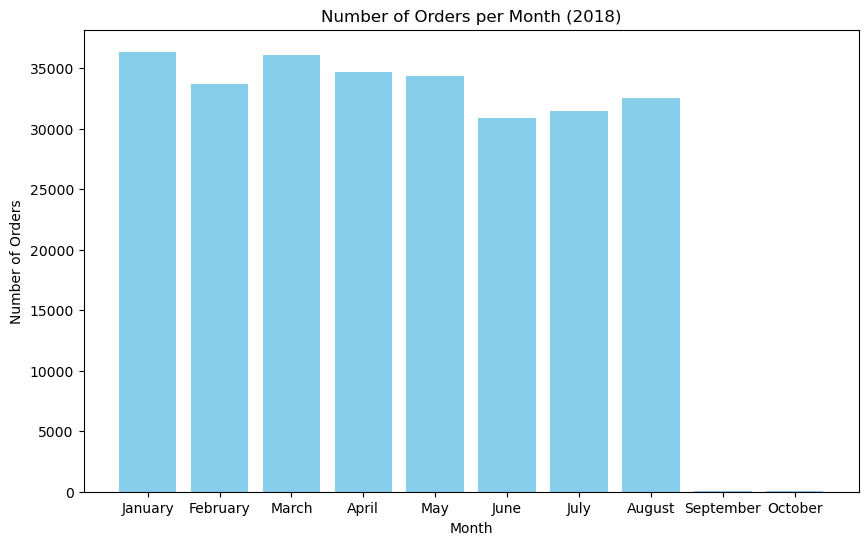

In [9]:
query = """ SELECT MONTHNAME(order_purchase_timestamp), COUNT(order_id)
            FROM orders
            WHERE YEAR(order_purchase_timestamp) = 2018
            GROUP BY MONTHNAME(order_purchase_timestamp) """

cur.execute(query)

data = cur.fetchall()

# Create DataFrame with proper column names
df = pd.DataFrame(data, columns=['Month', 'No. of Orders'])  # Define column names here

month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

df = df.sort_values('Month')

# Plot the bar chart
plt.figure(figsize=(10, 6))
plt.bar(df['Month'], df['No. of Orders'], color='skyblue')
plt.title("Number of Orders per Month (2018)")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

##  Find the average number of products per order, grouped by customer city.


In [10]:
query = """ WITH count_per_order AS
            (SELECT o.customer_id, o.order_id, COUNT(oi.order_id) AS CpO FROM
            orders o JOIN order_items oi ON o.order_id = oi.order_id JOIN
            customers c ON c.customer_id = o.customer_id
            GROUP BY  o.customer_id, o.order_id)

            SELECT c.customer_state, ROUND(AVG(cpo.CpO),2) FROM
            customers c JOIN count_per_order cpo ON c.customer_id = cpo.customer_id
            GROUP BY c.customer_state; """

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["State","Average no. of Products/Order"])
df.head()

,State,Average no. of Products/Order
0,SP,143.35
1,RS,143.48
2,SC,144.52
3,RJ,142.80
4,MG,142.16


##  Calculate the percentage of total revenue contributed by each product category.

In [11]:
query = """ SELECT pro.product_category AS Product_Category,  ROUND((SUM(p.payment_value)/(SELECT SUM(p.payment_value) FROM payments p))*100,2) AS Perc_Contribution FROM order_items oi JOIN payments p ON oi.order_id = p.order_id
JOIN products pro ON pro.product_id = oi.product_id
GROUP BY pro.product_category ORDER BY Perc_Contribution DESC"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Product Category","%age Contribution in Sales"])
df

,Product Category,%age Contribution in Sales
0,bed table bath,267.44
1,HEALTH BEAUTY,258.82
2,computer accessories,247.57
3,Furniture Decoration,223.34
4,Watches present,223.19
...,...,...
69,PC Gamer,0.34
70,House Comfort 2,0.27
71,cds music dvds,0.19
72,Fashion Children's Clothing,0.12


##  Identify the correlation between product price and the number of times a product has been purchased.


In [12]:
query = """ SELECT p.product_category, COUNT(oi.product_id) AS Quantity, ROUND(AVG(oi.price),2) AS Price_of_one FROM products p JOIN order_items oi
            ON p.product_id = oi.product_id 
            GROUP BY p.product_category;"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Category","Quantity","Price per Piece"])


correlation = df["Quantity"].corr(df["Price per Piece"])
print("Correlation between product price and the number of times a product has been purchased is  :", correlation, " i.e., no correlation.")

Correlation between product price and the number of times a product has been purchased is  : -0.10631514167157564  i.e., no correlation.


##  Calculate the total revenue generated by each seller, and rank them by revenue.


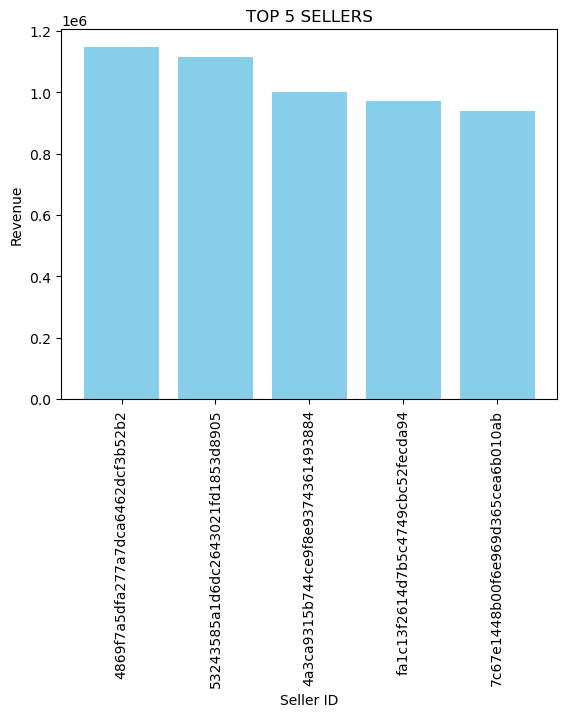

In [13]:
query = """ SELECT *, DENSE_RANK() OVER(ORDER BY Revenue DESC) AS RANKING FROM 
            (SELECT seller_id, ROUND(SUM(price),2) AS Revenue FROM order_items 
            GROUP BY  seller_id) AS Seller_Revenue;"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Seller ID","Revenue","Ranking"])
df=df.head()

plt.bar(df['Seller ID'], df['Revenue'], color='skyblue')
plt.xticks(rotation = 90)
plt.title("TOP 5 SELLERS")
plt.xlabel("Seller ID")
plt.ylabel("Revenue")
plt.show()

## Calculate the moving average of order values for each customer over their order history.

In [14]:
query = """ SELECT o.customer_id, o.order_purchase_timestamp, pay.payment_value , AVG(pay.payment_value) 
            OVER(PARTITION BY o.customer_id ORDER BY o.order_purchase_timestamp
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) AS mov_avg
            FROM orders o JOIN payments pay 
            ON o.order_id = pay.order_id;"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Customer ID","TIMESTAMP","Price","Moving Avg."])
df

,Customer ID,TIMESTAMP,Price,Moving Avg.
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
2,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
3,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
4,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
...,...,...,...,...
2597145,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
2597146,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
2597147,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
2597148,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001


##  Calculate the cumulative sales per month for each year.

In [15]:
query = """ SELECT Years, Months, Payment, SUM(Payment) OVER(ORDER BY Years, Months) AS Cummulative_Payment FROM
            (SELECT YEAR(o.order_purchase_timestamp) AS Years, MONTH(o.order_purchase_timestamp) AS Months ,ROUND(SUM(pay.payment_value),2) AS Payment
            FROM orders o JOIN payments pay ON o.order_id = pay.order_id GROUP BY Years, Months ORDER BY Years, Months) AS ppmy;"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Year", "Month","Sales Over Month","Cummulative Sales"])

df

,Year,Month,Sales Over Month,Cummulative Sales
0,2016,9,6306.00,6.306000e+03
1,2016,10,1477262.00,1.483568e+06
2,2016,12,490.50,1.484058e+06
3,2017,1,3462201.00,4.946260e+06
4,2017,2,7297700.24,1.224396e+07
5,2017,3,11246589.99,2.349055e+07
6,2017,4,10444700.74,3.393525e+07
7,2017,5,14822970.50,4.875822e+07
8,2017,6,12781909.51,6.154013e+07
9,2017,7,14809572.99,7.634970e+07


##  Calculate the year-over-year growth rate of total sales.


In [16]:
query = """WITH a AS
            (SELECT YEAR(o.order_purchase_timestamp) AS Years,ROUND(SUM(pay.payment_value),2) AS Payment
            FROM orders o JOIN payments pay ON o.order_id = pay.order_id GROUP BY Years ORDER BY Years)
            
            SELECT Years, Payment, lag(Payment, 1) OVER(ORDER BY Years), 
            ((Payment-lag(Payment, 1) OVER(ORDER BY Years))/lag(Payment, 1) OVER(ORDER BY Years))*100 AS YOY FROM a;"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["Year", "Total Sales","Last Year Sales","YOY %age"])
df

,Year,Total Sales,Last Year Sales,YOY %age
0,2016,1.484058e+06,NaN,NaN
1,2017,1.812437e+08,1.484058e+06,12112.703759
2,2018,2.174941e+08,1.812437e+08,20.000924


## Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [17]:
query = """with a as (select customers.customer_id,
min(orders.order_purchase_timestamp) first_order
from customers join orders
on customers.customer_id = orders.customer_id
group by customers.customer_id),

b as (select a.customer_id, count(distinct orders.order_purchase_timestamp) next_order
from a join orders
on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp > first_order
and orders.order_purchase_timestamp < 
date_add(first_order, interval 6 month)
group by a.customer_id) 

select 100 * (count( distinct a.customer_id)/ count(distinct b.customer_id)) 
from a left join b 
on a.customer_id = b.customer_id ;"""

cur.execute(query)
data = cur.fetchall()

data

[(None,)]

## Identify the top 3 customers who spent the most money in each year.


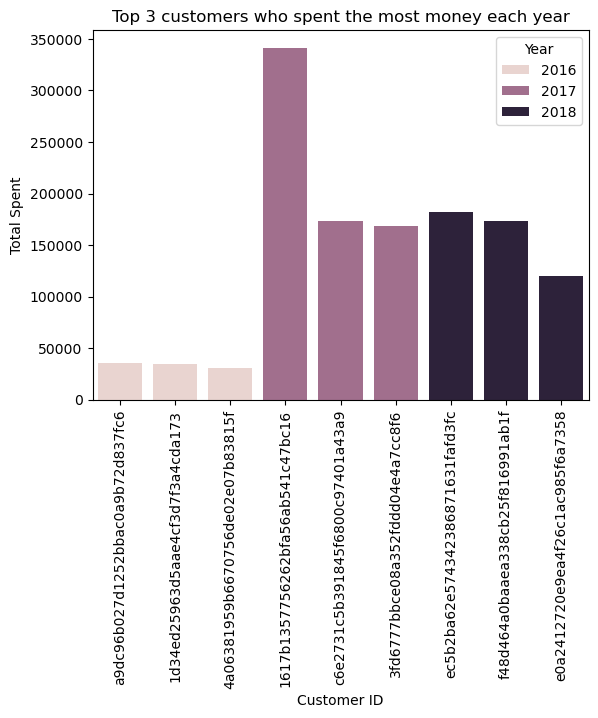

In [18]:
query = """SELECT Years, Customer_ID, Payment, D_Rank FROM
(SELECT YEAR(o.order_purchase_timestamp) AS Years, o.customer_id AS Customer_ID, 
	SUM(pay.payment_value) AS Payment, DENSE_RANK() OVER(PARTITION BY YEAR(o.order_purchase_timestamp) ORDER BY SUM(pay.payment_value) DESC) AS D_Rank
    FROM orders o JOIN payments pay  ON o.order_id = pay.order_id 
    GROUP BY  Years, o.customer_id) AS a
WHERE D_Rank <= 3;"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Year", "Customer ID","Total Spent","Ranking over Year"])
sns.barplot(x = "Customer ID", y = "Total Spent", data = df, hue = "Year")
plt.xticks(rotation = 90)
plt.title("Top 3 customers who spent the most money each year")
plt.show()
